# Notebook 01 — Exploration des données
**Projet :** Prévision du crédit bancaire dans la zone UEMOA (2000-2024)  
**Phase J3 :** Statistiques descriptives, distributions, corrélations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

pd.set_option('display.float_format', '{:.3f}'.format)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

DATA_PATH = Path('../data/panel_uemoa_complet.csv')
FIG_PATH = Path('../figures')
FIG_PATH.mkdir(exist_ok=True)

## 1. Chargement et aperçu du panel

In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Dimensions : {df.shape[0]} observations × {df.shape[1]} variables")
print(f"Pays : {sorted(df['pays'].unique())}")
print(f"Période : {df['annee'].min()} – {df['annee'].max()}")
df.head()

Dimensions : 200 observations × 28 variables
Pays : ['Benin', 'Burkina Faso', "Cote d'Ivoire", 'Guinee-Bissau', 'Mali', 'Niger', 'Senegal', 'Togo']
Période : 2000 – 2024


,iso3,pays,annee,credit_prive_pib,pib_croissance,pib_par_habitant_croissance,inflation_ipc,masse_monetaire_m2_pib,recettes_fiscales_pib,dette_publique_pib,...,imf_inflation,imf_solde_budgetaire,imf_dette_publique,imf_balance_courante,wgi_controle_corruption,wgi_efficacite_gouvernement,wgi_stabilite_politique,wgi_etat_droit,wgi_qualite_reglementaire,bceao_taux_directeur
0,BEN,Benin,2000,7.761,5.858,2.650,4.165,19.189,NaN,39.600,...,4.200,-3.700,39.600,-2.300,-0.835,-0.796,0.617,-0.284,-0.244,6.500
1,BEN,Benin,2001,7.182,5.333,2.165,3.984,17.998,NaN,38.000,...,4.000,-3.300,38.000,-2.000,NaN,NaN,NaN,NaN,NaN,6.500
2,BEN,Benin,2002,7.638,4.643,1.510,2.489,14.641,NaN,30.800,...,2.400,-3.300,30.800,-3.700,-0.841,-0.636,0.619,-0.391,-0.556,6.500
3,BEN,Benin,2003,9.473,3.444,0.337,1.487,16.788,NaN,23.400,...,1.500,-1.100,23.400,-6.200,-0.843,-0.645,0.577,-0.472,-0.556,5.500
4,BEN,Benin,2004,9.559,4.430,1.281,0.874,14.034,NaN,21.500,...,0.900,-0.700,21.500,-4.700,-0.509,-0.446,0.177,-0.386,-0.608,4.500


## 2. Valeurs manquantes

In [3]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'Manquants': missing, 'Complétude (%)': (100 - missing_pct)})
missing_df = missing_df[missing_df['Manquants'] > 0].sort_values('Manquants', ascending=False)
print(missing_df.to_string())

                             Manquants  Complétude (%)
atm_100k                           114          43.000
recettes_fiscales_pib               97          51.500
agences_bancaires_100k              48          76.000
wgi_etat_droit                       8          96.000
wgi_stabilite_politique              8          96.000
wgi_controle_corruption              8          96.000
wgi_efficacite_gouvernement          8          96.000
wgi_qualite_reglementaire            8          96.000
dette_publique_pib                   7          96.500
imf_dette_publique                   7          96.500
ouverture_commerciale                2          99.000


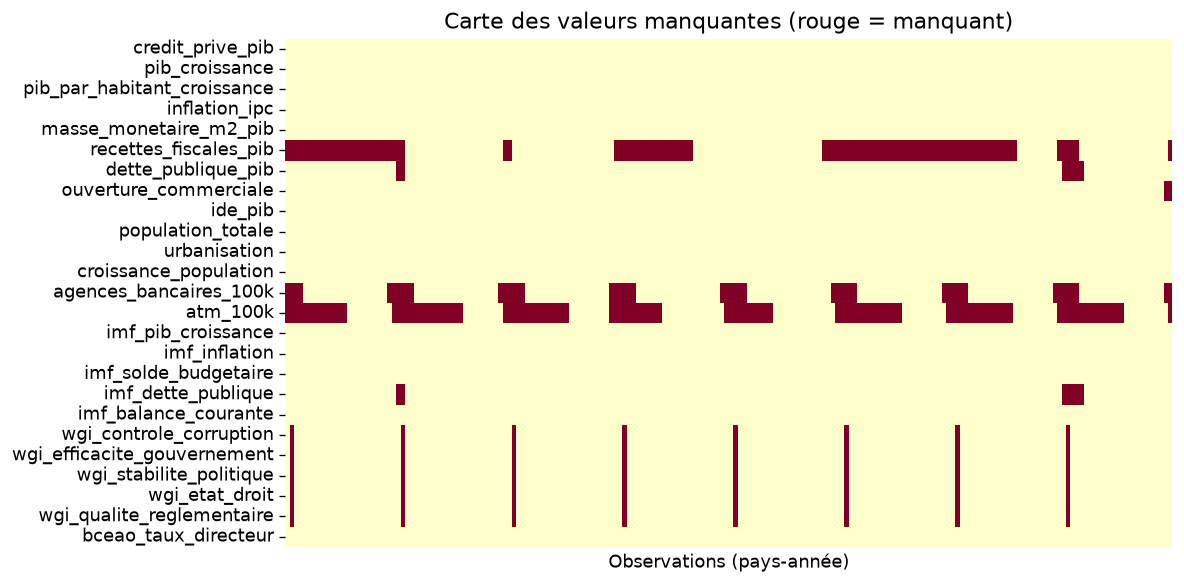

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
cols_numeric = df.select_dtypes(include='number').columns.drop(['annee'])
missing_matrix = df[cols_numeric].isnull()
sns.heatmap(missing_matrix.T, cmap='YlOrRd', cbar=False, ax=ax,
            xticklabels=False, yticklabels=True)
ax.set_title('Carte des valeurs manquantes (rouge = manquant)')
ax.set_xlabel('Observations (pays-année)')
plt.tight_layout()
plt.savefig(FIG_PATH / 'missing_heatmap.png', bbox_inches='tight')
plt.show()

## 3. Statistiques descriptives

In [5]:
vars_principales = [
    'credit_prive_pib', 'pib_croissance', 'inflation_ipc',
    'masse_monetaire_m2_pib', 'dette_publique_pib',
    'ouverture_commerciale', 'ide_pib',
    'wgi_controle_corruption', 'wgi_stabilite_politique',
    'bceao_taux_directeur', 'imf_balance_courante'
]
df[vars_principales].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
credit_prive_pib,200.000,15.626,7.449,0.733,10.382,14.234,20.825,32.159
pib_croissance,200.000,4.398,2.895,-5.370,2.824,4.784,6.242,15.806
inflation_ipc,200.000,2.438,2.840,-3.503,0.720,1.923,3.704,14.290
masse_monetaire_m2_pib,200.000,26.372,10.830,6.556,18.486,23.922,33.446,52.781
dette_publique_pib,193.000,51.875,37.784,8.400,29.900,44.300,60.100,217.100
ouverture_commerciale,198.000,51.581,10.238,30.368,44.709,51.329,58.946,82.148
ide_pib,200.000,2.194,2.445,-2.575,0.887,1.617,2.716,15.604
wgi_controle_corruption,192.000,-0.611,0.390,-1.664,-0.849,-0.564,-0.363,0.364
wgi_stabilite_politique,192.000,-0.650,0.718,-2.558,-0.961,-0.539,-0.184,0.619
bceao_taux_directeur,200.000,4.230,0.995,3.500,3.500,3.500,4.500,6.500


In [6]:
print("=== Statistiques par pays — Variable cible (crédit privé / PIB) ===")
df.groupby('pays')['credit_prive_pib'].describe().round(2)

=== Statistiques par pays — Variable cible (crédit privé / PIB) ===


,count,mean,std,min,25%,50%,75%,max
pays,,,,,,,,
Benin,25.000,14.340,3.610,7.180,11.320,15.810,16.700,18.950
Burkina Faso,25.000,19.990,7.650,8.860,13.300,16.640,27.160,31.910
Cote d'Ivoire,25.000,14.520,4.740,8.830,9.860,12.440,19.220,22.500
Guinee-Bissau,25.000,7.620,4.840,0.730,2.900,9.190,11.990,14.190
Mali,25.000,17.070,4.450,11.370,13.320,15.070,21.730,24.720
Niger,25.000,8.810,2.980,3.680,6.420,10.140,11.160,12.980
Senegal,25.000,23.270,6.110,13.750,18.370,23.740,29.270,32.160
Togo,25.000,19.400,7.790,7.650,11.500,21.770,26.160,30.350


## 4. Évolution temporelle de la variable cible

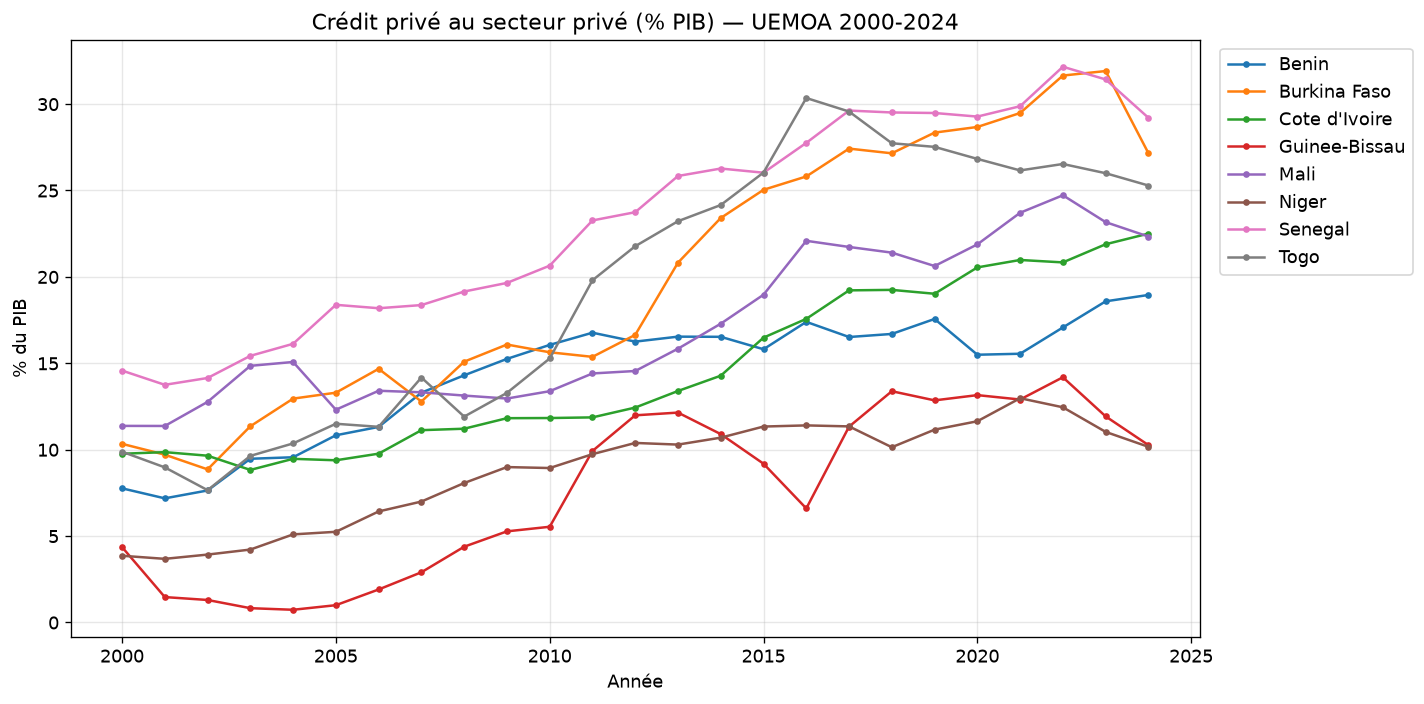

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))
pays_list = sorted(df['pays'].unique())
palette = sns.color_palette('tab10', n_colors=len(pays_list))

for pays, color in zip(pays_list, palette):
    subset = df[df['pays'] == pays].sort_values('annee')
    ax.plot(subset['annee'], subset['credit_prive_pib'],
            label=pays, color=color, marker='o', markersize=3, linewidth=1.5)

ax.set_title('Crédit privé au secteur privé (% PIB) — UEMOA 2000-2024')
ax.set_xlabel('Année')
ax.set_ylabel('% du PIB')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_PATH / 'credit_prive_evolution.png', bbox_inches='tight')
plt.show()

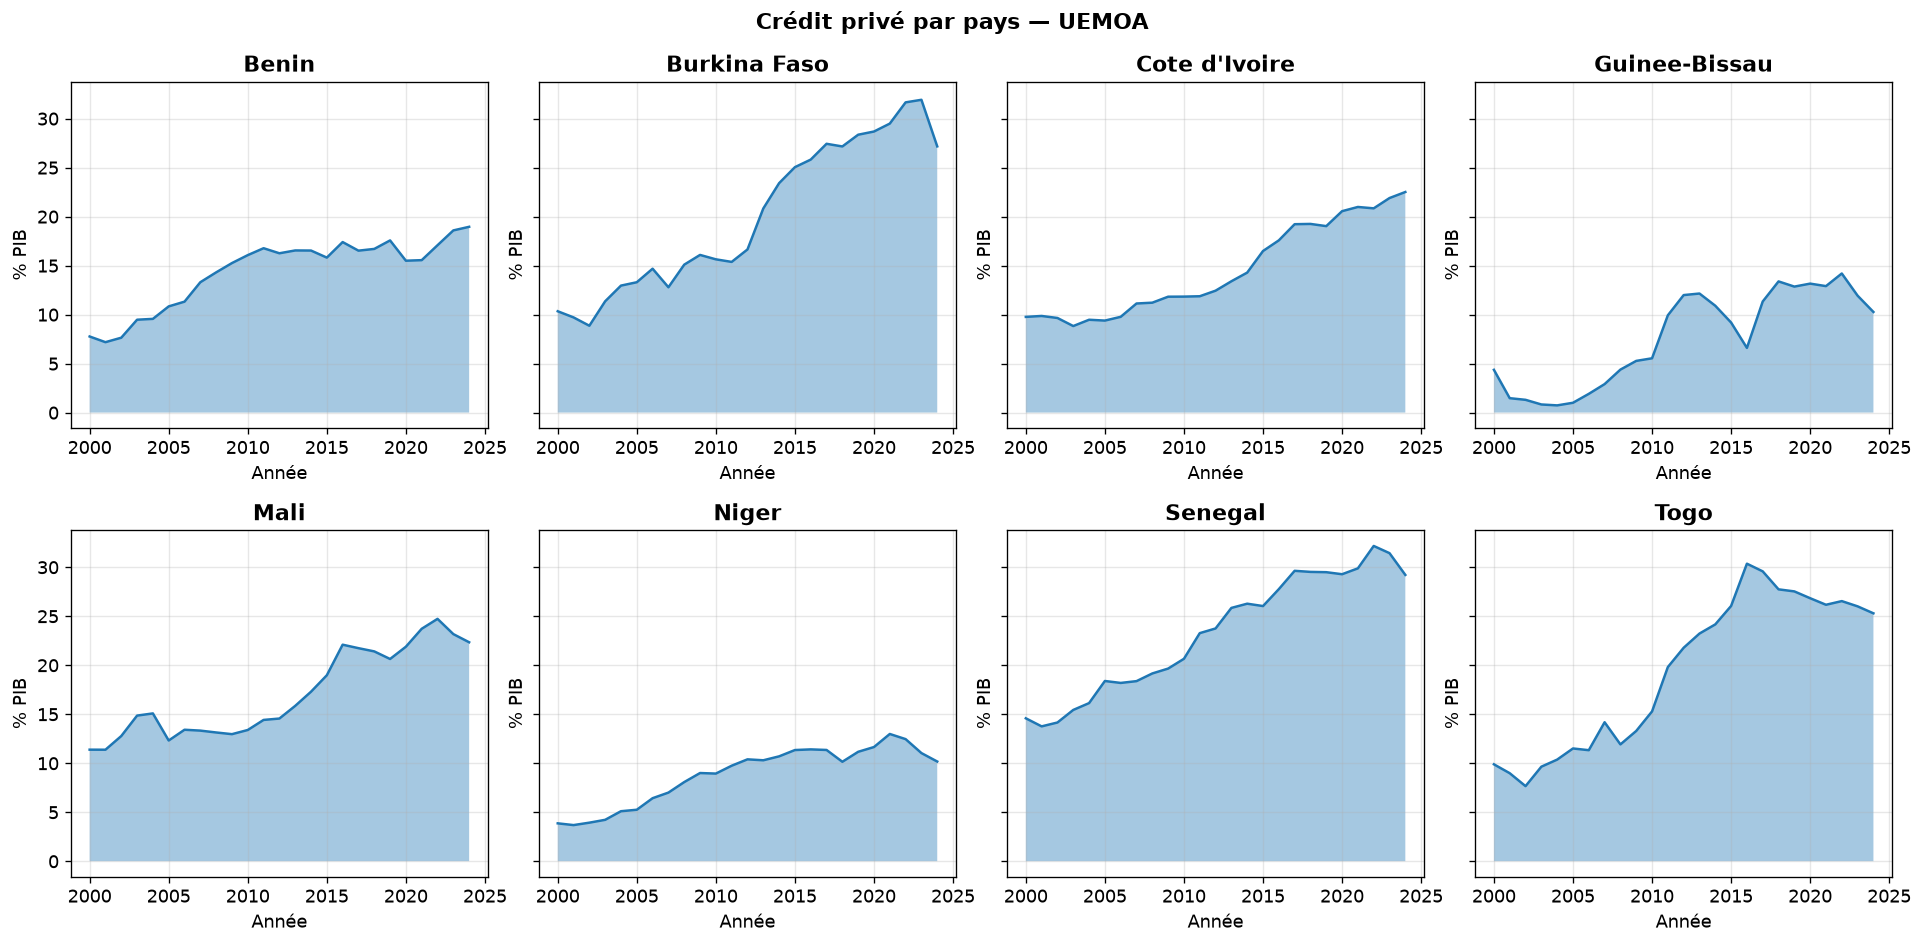

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharey=True)
for ax, pays in zip(axes.flatten(), pays_list):
    subset = df[df['pays'] == pays].sort_values('annee')
    ax.fill_between(subset['annee'], subset['credit_prive_pib'], alpha=0.4)
    ax.plot(subset['annee'], subset['credit_prive_pib'], linewidth=1.5)
    ax.set_title(pays, fontweight='bold')
    ax.set_xlabel('Année')
    ax.set_ylabel('% PIB')
    ax.grid(alpha=0.3)
fig.suptitle('Crédit privé par pays — UEMOA', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_PATH / 'credit_prive_par_pays.png', bbox_inches='tight')
plt.show()

## 5. Distribution de la variable cible

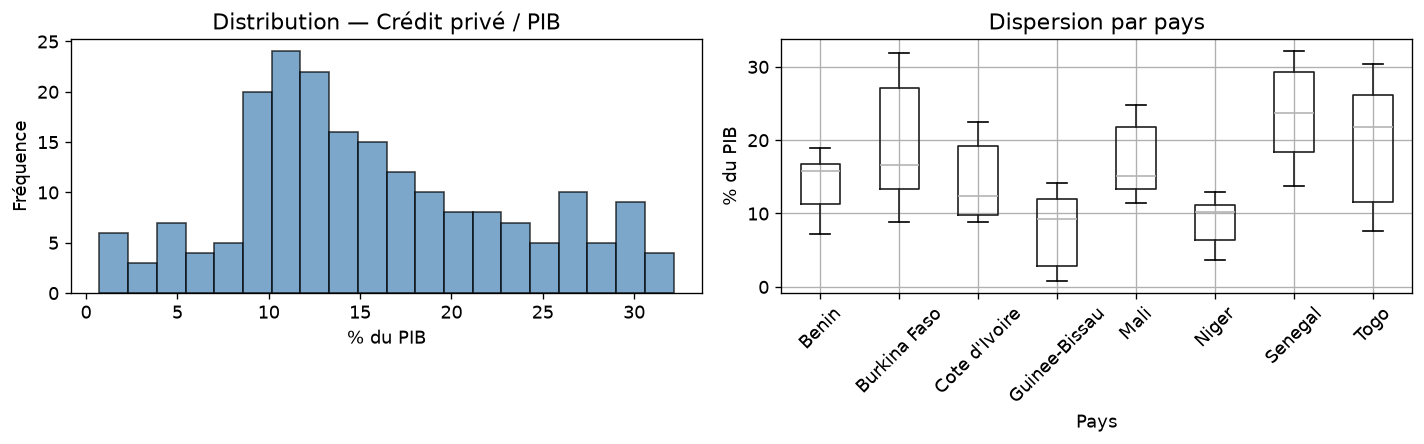

Test de normalité (D'Agostino-Pearson) : stat=8.255, p=0.0161
→ Distribution non normale au seuil 5%


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['credit_prive_pib'].dropna(), bins=20, edgecolor='black', color='steelblue', alpha=0.7)
axes[0].set_title('Distribution — Crédit privé / PIB')
axes[0].set_xlabel('% du PIB')
axes[0].set_ylabel('Fréquence')

df.boxplot(column='credit_prive_pib', by='pays', ax=axes[1], rot=45)
axes[1].set_title('Dispersion par pays')
axes[1].set_xlabel('Pays')
axes[1].set_ylabel('% du PIB')
plt.suptitle('')

plt.tight_layout()
plt.savefig(FIG_PATH / 'credit_distribution.png', bbox_inches='tight')
plt.show()

from scipy import stats
stat, p = stats.normaltest(df['credit_prive_pib'].dropna())
print(f"Test de normalité (D'Agostino-Pearson) : stat={stat:.3f}, p={p:.4f}")
print("→ Distribution" + (" normale" if p > 0.05 else " non normale") + f" au seuil 5%")

## 6. Matrice de corrélations

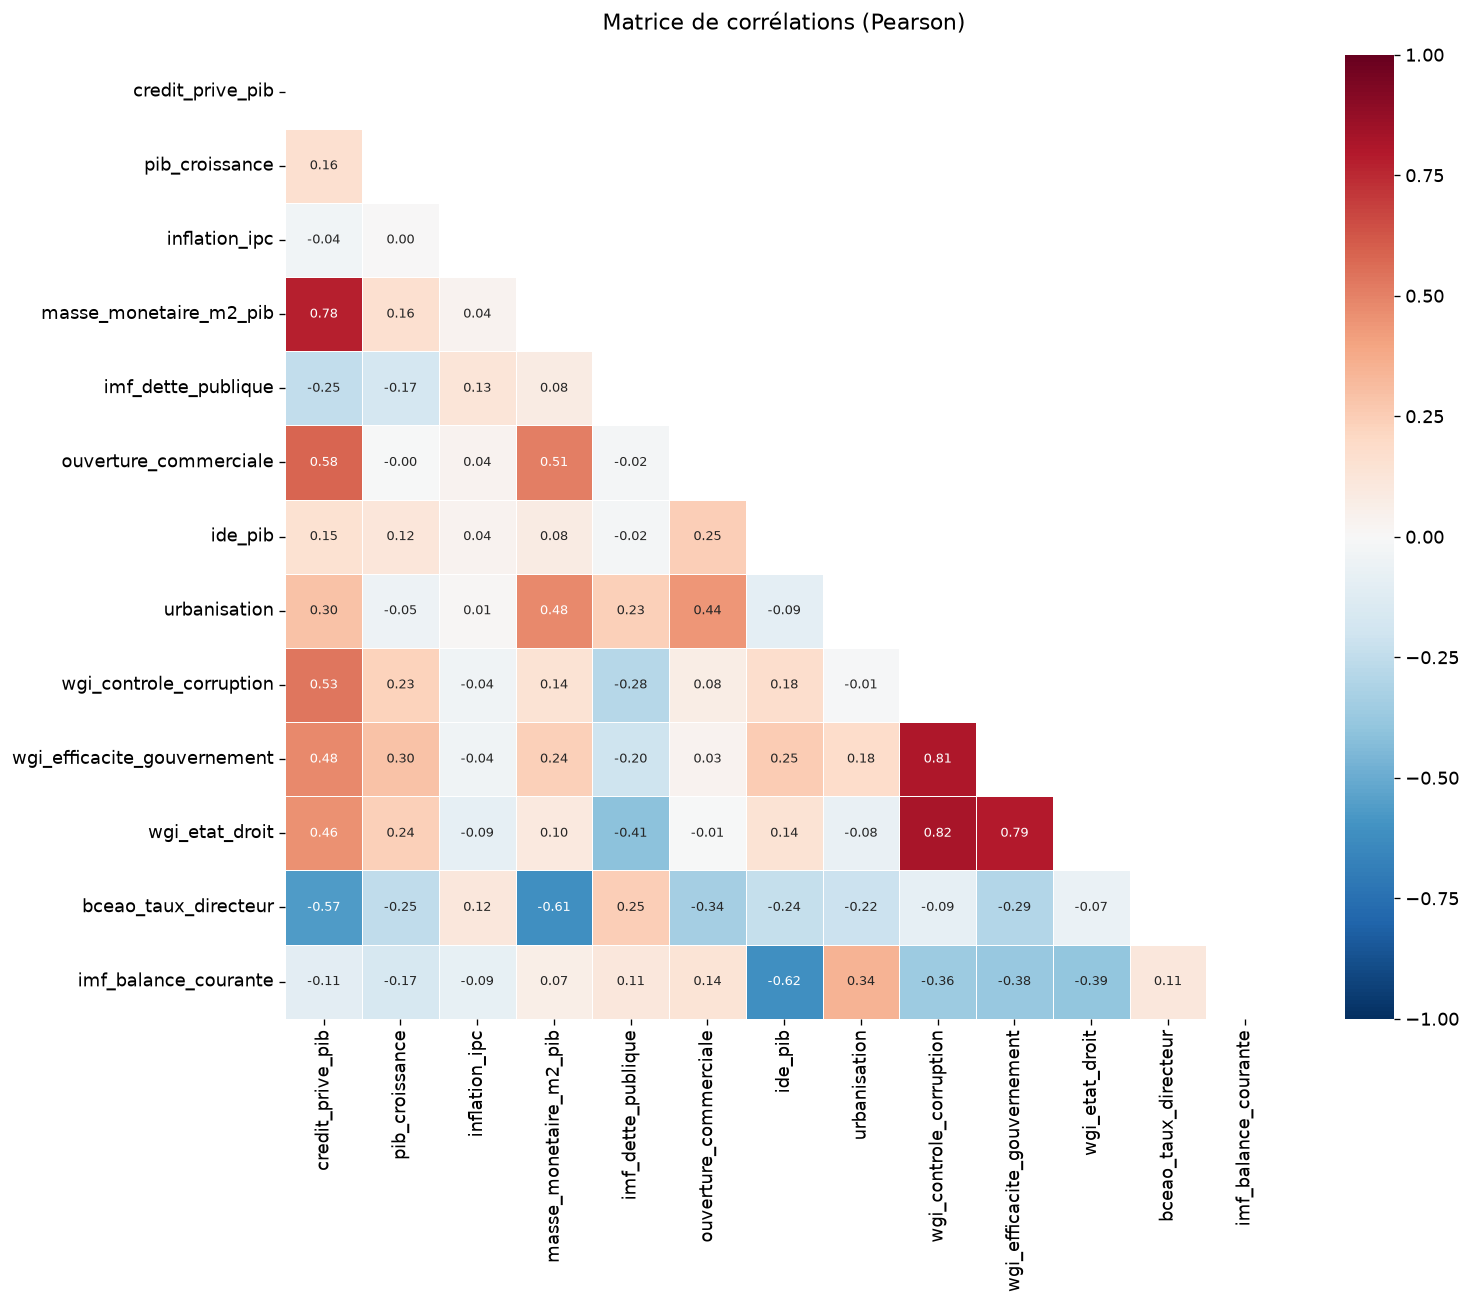

In [10]:
vars_corr = [
    'credit_prive_pib', 'pib_croissance', 'inflation_ipc',
    'masse_monetaire_m2_pib', 'imf_dette_publique',
    'ouverture_commerciale', 'ide_pib', 'urbanisation',
    'wgi_controle_corruption', 'wgi_efficacite_gouvernement',
    'wgi_etat_droit', 'bceao_taux_directeur', 'imf_balance_courante'
]
corr_matrix = df[vars_corr].corr()

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.3,
            annot_kws={'size': 8})
ax.set_title('Matrice de corrélations (Pearson)', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig(FIG_PATH / 'correlation_matrix.png', bbox_inches='tight')
plt.show()

In [11]:
corr_cible = corr_matrix['credit_prive_pib'].drop('credit_prive_pib').sort_values(key=abs, ascending=False)
print("=== Corrélations avec credit_prive_pib (classées par |r|) ===")
for var, val in corr_cible.items():
    sens = '(+)' if val > 0 else '(-)'
    print(f"  {sens} {var:<40} r = {val:+.3f}")

=== Corrélations avec credit_prive_pib (classées par |r|) ===
  (+) masse_monetaire_m2_pib                   r = +0.775
  (+) ouverture_commerciale                    r = +0.583
  (-) bceao_taux_directeur                     r = -0.569
  (+) wgi_controle_corruption                  r = +0.531
  (+) wgi_efficacite_gouvernement              r = +0.478
  (+) wgi_etat_droit                           r = +0.457
  (+) urbanisation                             r = +0.295
  (-) imf_dette_publique                       r = -0.249
  (+) pib_croissance                           r = +0.156
  (+) ide_pib                                  r = +0.149
  (-) imf_balance_courante                     r = -0.106
  (-) inflation_ipc                            r = -0.039


## 7. Focus Bénin — variable cible

Observations Bénin : 25 | Période : 2000–2024
Crédit privé Bénin — min: 7.18% | max: 18.95% | moy: 14.34%


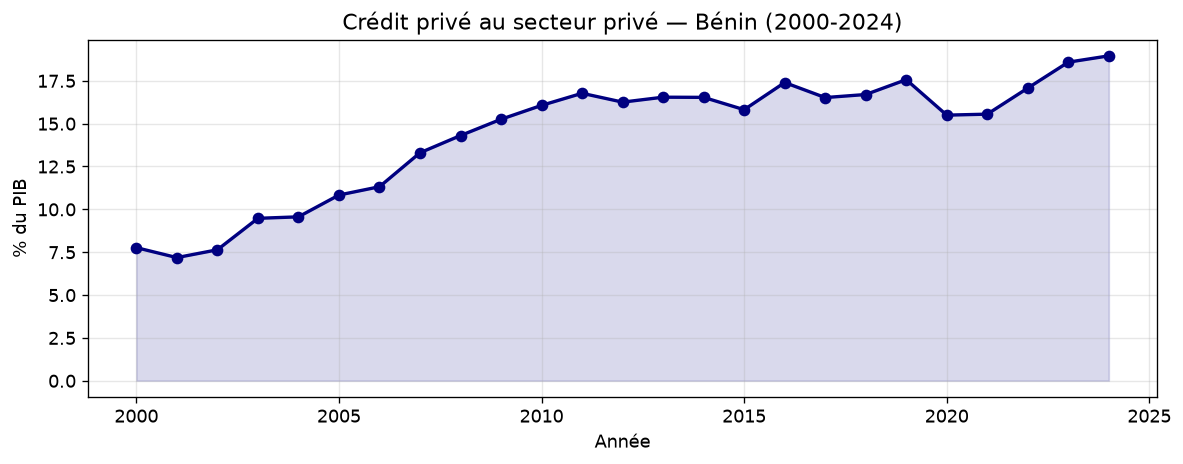

In [12]:
benin = df[df['iso3'] == 'BEN'].sort_values('annee').copy()
print(f"Observations Bénin : {len(benin)} | Période : {benin['annee'].min()}–{benin['annee'].max()}")
print(f"Crédit privé Bénin — min: {benin['credit_prive_pib'].min():.2f}% | "
      f"max: {benin['credit_prive_pib'].max():.2f}% | moy: {benin['credit_prive_pib'].mean():.2f}%")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(benin['annee'], benin['credit_prive_pib'], 'o-', color='navy', linewidth=2)
ax.fill_between(benin['annee'], benin['credit_prive_pib'], alpha=0.15, color='navy')
ax.set_title('Crédit privé au secteur privé — Bénin (2000-2024)')
ax.set_xlabel('Année')
ax.set_ylabel('% du PIB')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_PATH / 'credit_benin.png', bbox_inches='tight')
plt.show()

## 8. Synthèse

**Points clés identifiés :**
- Hétérogénéité marquée entre pays (Côte d'Ivoire et Sénégal dominent)
- Variable cible complète à 100% sur tout le panel
- Corrélations à documenter pour la sélection de variables des modèles
- Bénin : trajectoire à analyser en profondeur pour l'ARDL

→ **Étape suivante : Notebook 02 — Tests statistiques (stationnarité, Hausman)**